# Notebook 00: Lung cell annotation validation

**Purpose:** Validate the published lung cell labels before defining alveolar macrophages or MHCII-high/low AM states.

**Status:** Local technical-validation notebook. A published `Macrophages` label is treated only as a macrophage candidate pool.

## tl;dr

This notebook first verifies the source object and published labels. It does **not** equate all `Macrophages` with alveolar macrophages and does not assign MHCII states. Executed evidence and limitations are summarized under **Takeaways**.

## Context & Methods

### Cell definitions being checked

- **Macrophage candidate pool:** `celltype_final == "Macrophages"`. This is not yet an AM definition.
- **AT1 candidate:** `celltype_final == "AT1"`.
- **AT2 candidate:** `celltype_final == "AT2"`.

The subsequent marker analysis will compare alveolar-macrophage evidence (`MARCO`, `APOE`) with interstitial-macrophage and monocyte alternatives. No AM inclusion flag will be created in this notebook.

### Key assumptions

The master H5AD is authoritative. `X` is used only after its transformation is reported. `raw.X` is preserved for later count-aware work. Donor is the biological replicate; cells are not independent replicates. Local mode may select cores, but it never subsamples cells inside a selected core for spatial work.

### 1. Parameters

This visible cell selects local or HPC paths. Environment variables can override defaults without editing scientific code.

In [1]:
from pathlib import Path
import os

RUN_MODE = os.getenv('XTY_AM_RUN_MODE', 'local_test')
RANDOM_SEED = 20260912
LOCAL_DATA_DIR = Path(r'D:\Xiaonan\CODEX_projects\Xiaotong_AM\Spatial\Spatial')
HPC_DATA_DIR = Path('/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/data/Spatial')
DATA_DIR = Path(os.getenv('XTY_AM_DATA_DIR', LOCAL_DATA_DIR if RUN_MODE == 'local_test' else HPC_DATA_DIR))
OUTPUT_ROOT = Path(os.getenv('XTY_AM_OUTPUT_ROOT', Path.cwd() / 'outputs' / RUN_MODE))
DATA_PATH = DATA_DIR / 'xenium.h5ad'
N_LOCAL_CORES = 4
assert RUN_MODE in {'local_test', 'hpc_full'}
print({'run_mode': RUN_MODE, 'data_path': str(DATA_PATH), 'output_root': str(OUTPUT_ROOT)})

{'run_mode': 'local_test', 'data_path': 'D:\\Xiaonan\\CODEX_projects\\Xiaotong_AM\\Spatial\\Spatial\\xenium.h5ad', 'output_root': 'D:\\Xiaonan\\CODEX_projects\\Xiaotong_AM\\XTY_AM_project\\.worktrees\\notebook-00-annotation-validation\\outputs\\local_test'}


## Data

### 2. Load the master H5AD in backed mode

Backed mode avoids loading the full expression matrix before genes are requested.

In [2]:
import json
import platform
import sys

import anndata as ad
import numpy as np
import pandas as pd

assert DATA_PATH.exists(), f'Missing input: {DATA_PATH}'
adata = ad.read_h5ad(DATA_PATH, backed='r')
print(f'Loaded {adata.n_obs:,} cells x {adata.n_vars:,} genes')
print(f'Python {platform.python_version()} | anndata {ad.__version__}')

Loaded 332,063 cells x 389 genes
Python 3.12.14 | anndata 0.13.3.post0


D:\Xiaonan\CODEX_projects\Xiaotong_AM\.analysis_tmp\ipykernel_26748\3718358925.py:12: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print(f'Python {platform.python_version()} | anndata {ad.__version__}')


### 3. Validate observation grain and spatial coordinates

Each row must be one unique segmented cell. Donor, core, region, published cell type, QC fields, UMAP coordinates, and spatial centroids are required. Coordinates from different cores are never combined as one spatial field.

In [3]:
required_obs = {
    'donor_id', 'core_id', 'tissue_annotation', 'celltype_final',
    'x_centroid', 'y_centroid', 'n_counts', 'n_genes',
}
missing_obs = sorted(required_obs.difference(adata.obs.columns))
assert not missing_obs, f'Missing required obs columns: {missing_obs}'
assert adata.obs_names.is_unique, 'Cell identifiers are not unique'
assert 'X_umap' in adata.obsm, 'Missing X_umap embedding'
assert 'spatial' in adata.obsm, 'Missing spatial coordinates'
assert adata.obsm['X_umap'].shape == (adata.n_obs, 2)
assert adata.obsm['spatial'].shape == (adata.n_obs, 2)

required_nonmissing = ['donor_id', 'core_id', 'tissue_annotation', 'celltype_final', 'x_centroid', 'y_centroid']
missing_counts = adata.obs[required_nonmissing].isna().sum()
assert int(missing_counts.sum()) == 0, missing_counts[missing_counts.gt(0)].to_dict()
print('Cell IDs, required metadata, UMAP, and spatial coordinates passed.')

Cell IDs, required metadata, UMAP, and spatial coordinates passed.


### 4. Count published labels and select complete local-test cores

Counts below describe source labels, not validated biological identities. Local cores are selected deterministically from eligible alveolar cores across the distribution of core sizes; every cell in each selected core is retained.

In [4]:
obs = adata.obs.copy()
celltype_counts = obs['celltype_final'].astype(str).value_counts().sort_values(ascending=False)
assert {'Macrophages', 'AT1', 'AT2'}.issubset(celltype_counts.index)

target_counts = pd.crosstab(obs['core_id'].astype(str), obs['celltype_final'].astype(str))
core_meta = obs.assign(core_id_string=obs['core_id'].astype(str)).groupby('core_id_string', observed=True).agg(
    donor_id=('donor_id', 'first'),
    tissue_annotation=('tissue_annotation', 'first'),
    n_cells=('celltype_final', 'size'),
)
core_summary = core_meta.join(target_counts[['Macrophages', 'AT1', 'AT2']], how='left').fillna(0)
core_summary.index.name = 'core_id'

eligible = core_summary.query("tissue_annotation == 'A' and Macrophages > 0 and AT1 > 0 and AT2 > 0").sort_values('n_cells')
assert len(eligible) >= N_LOCAL_CORES
positions = np.linspace(0, len(eligible) - 1, N_LOCAL_CORES).round().astype(int)
selected_cores = eligible.iloc[positions].index.tolist() if RUN_MODE == 'local_test' else core_summary.index.tolist()
selected_mask = obs['core_id'].astype(str).isin(selected_cores)
selected_obs = obs.loc[selected_mask].copy()

print('Published cell-type counts:')
display(celltype_counts.rename('n_cells').to_frame())
print('Selected complete cores:')
display(core_summary.loc[selected_cores])

Published cell-type counts:


,n_cells
celltype_final,
Endothelial,74225
Fibroblasts,66767
Monocytes,33479
Macrophages,33375
AT2,21495
AT1,20977
SmoothMuscle,12644
Pericytes,12553
CD8T,10603


Selected complete cores:


,donor_id,tissue_annotation,n_cells,Macrophages,AT1,AT2
core_id,,,,,,
D19.c2,D19,A,517,26,73,26
D17.c1,D17,A,3763,154,355,1181
D21.c1,D21,A,5538,545,483,363
D4.c3,D4,A,11865,514,1249,163


## Results

### 5. Machine-readable audit summary

This bounded JSON is used by the local integration test and records source-label counts without claiming AM identity.

In [5]:
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
summary = {
    'run_mode': RUN_MODE,
    'data_path': str(DATA_PATH),
    'n_cells': int(adata.n_obs),
    'n_genes': int(adata.n_vars),
    'duplicate_cell_ids': int(adata.n_obs - adata.obs_names.nunique()),
    'celltype_counts': {str(k): int(v) for k, v in celltype_counts.items()},
    'selected_cores': [str(x) for x in selected_cores],
    'selected_core_cells': int(selected_mask.sum()),
    'am_definition_status': 'not_finalized_macrophage_candidate_pool_only',
}
summary_path = OUTPUT_ROOT / 'notebook_00_summary.json'
summary_path.write_text(json.dumps(summary, indent=2), encoding='utf-8')
print(f'Wrote {summary_path}')
display(pd.Series(summary).to_frame('value'))

Wrote D:\Xiaonan\CODEX_projects\Xiaotong_AM\XTY_AM_project\.worktrees\notebook-00-annotation-validation\outputs\local_test\notebook_00_summary.json


,value
run_mode,local_test
data_path,D:\Xiaonan\CODEX_projects\Xiaotong_AM\Spatial\...
n_cells,332063
n_genes,389
duplicate_cell_ids,0
celltype_counts,"{'Endothelial': 74225, 'Fibroblasts': 66767, '..."
selected_cores,"[D19.c2, D17.c1, D21.c1, D4.c3]"
selected_core_cells,21683
am_definition_status,not_finalized_macrophage_candidate_pool_only


### 6. Marker definitions, statistics, and visual outputs

The source Macrophages label is a broad candidate pool, not an AM call. AM evidence (MARCO, APOE) is compared with IM alternatives (LYVE1, CD163, FCGR3A, MS4A4A), monocyte alternatives (FCN1, S100A12, IL1B, CLEC4E), and pan-macrophage support (CD68, AIF1, MPEG1, TYROBP). AT1 is checked with AGER and SCEL; AT2 with SFTPD and PLA2G4F.

Dot color is mean log-normalized X across all group cells. Dot area is the fraction with raw transcript count greater than zero. Program scores are only exploratory: each gene is standardized across macrophage candidates and measured genes in a program are averaged. No threshold, classifier, DE test, AM final flag, or MHCII state is created here.

In local_test, expression-heavy work uses four complete intact alveolar cores. HPC full mode uses all cells for marker summaries. UMAP rendering is stratified and deterministic; source counts remain full-object counts.

,gene,available,module
0,AGER,True,AT1 evidence
1,SCEL,True,AT1 evidence
2,SFTPD,True,AT2 evidence
3,PLA2G4F,True,AT2 evidence
4,MARCO,True,AM evidence
5,APOE,True,AM evidence
6,LYVE1,True,IM alternative
7,CD163,True,IM alternative
8,FCGR3A,True,IM alternative
9,MS4A4A,True,IM alternative


,source_celltype,gene,module,n_cells,mean_log_normalized_expression,fraction_detected_raw_gt_0
0,AT1,AGER,AT1 evidence,2160,4.588341,0.806019
1,AT1,SCEL,AT1 evidence,2160,3.982871,0.760648
2,AT1,SFTPD,AT2 evidence,2160,0.873482,0.186574
3,AT1,PLA2G4F,AT2 evidence,2160,0.103799,0.026389
4,AT1,MARCO,AM evidence,2160,0.328568,0.072222
5,AT1,APOE,AM evidence,2160,0.400402,0.090741
6,AT1,LYVE1,IM alternative,2160,0.269626,0.066204
7,AT1,CD163,IM alternative,2160,0.237565,0.055556
8,AT1,FCGR3A,IM alternative,2160,0.551122,0.121296
9,AT1,MS4A4A,IM alternative,2160,0.315386,0.073611


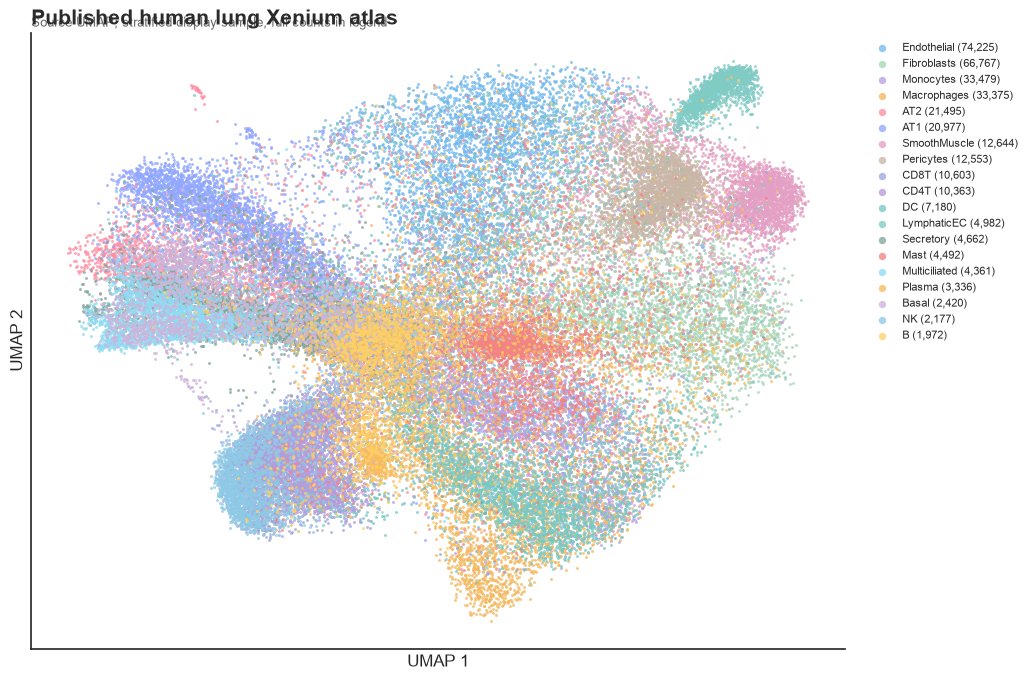

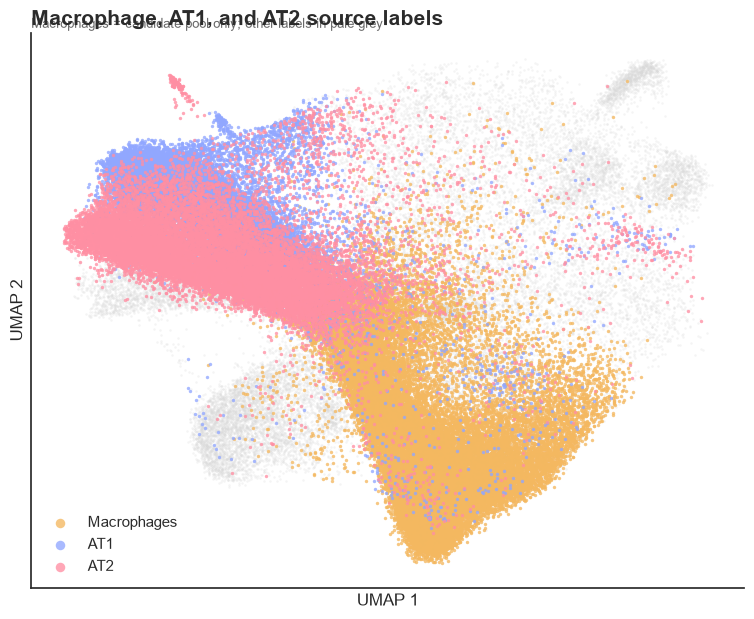

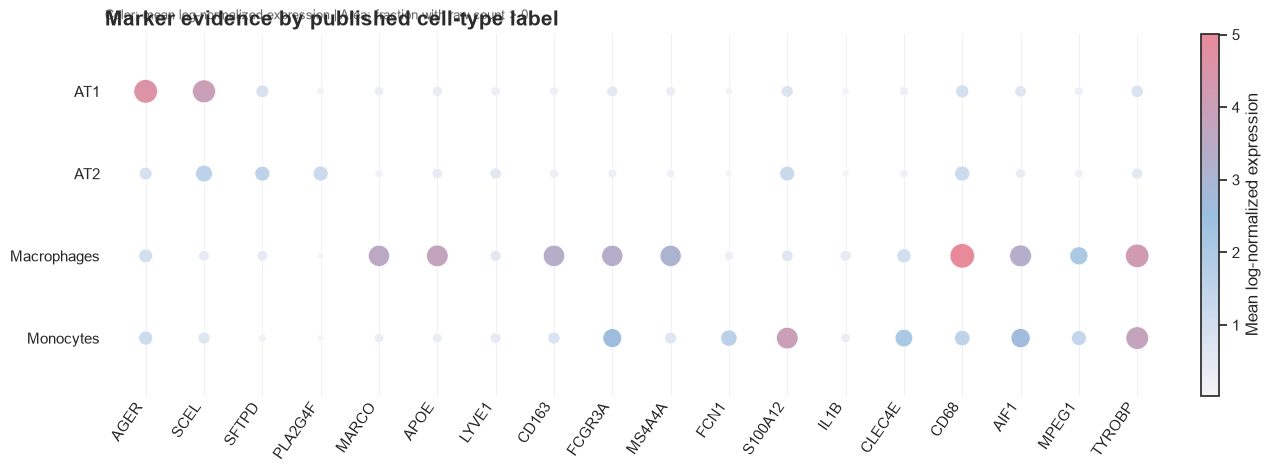

,count,mean,std,min,25%,50%,75%,max
AM evidence,1239.0,-6.773474e-08,0.860258,-1.333678,-0.564060,0.357625,0.776989,1.187550
IM alternative,1239.0,1.847311e-08,0.610905,-1.055726,-0.512588,0.034745,0.388901,1.833664
Monocyte alternative,1239.0,-2.155196e-08,0.535459,-0.390850,-0.390850,-0.390850,0.302781,2.340072


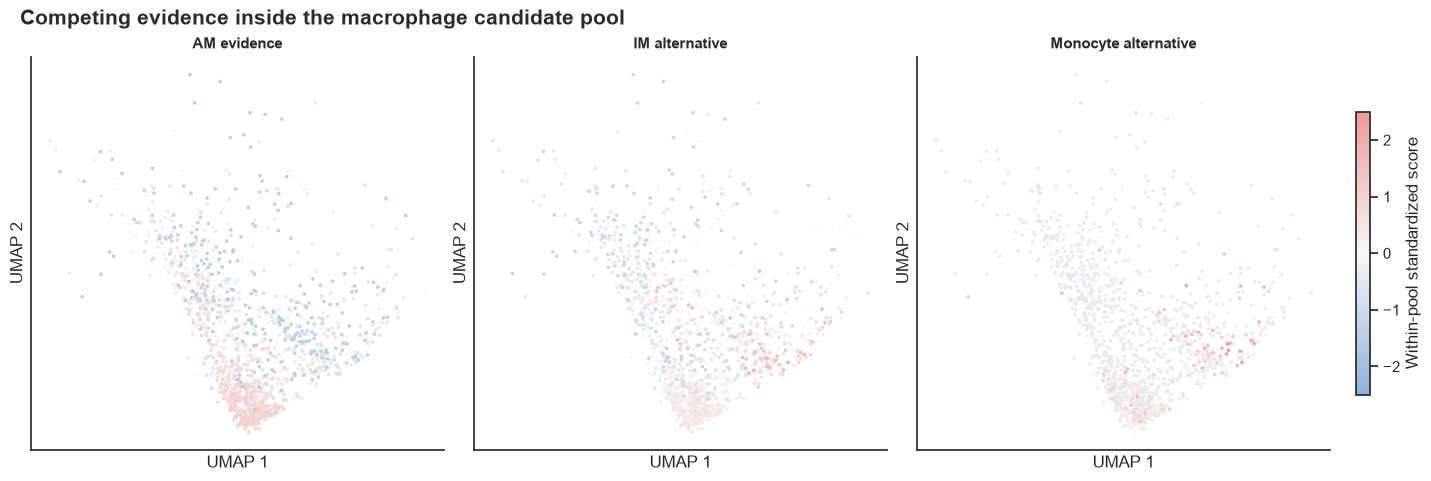

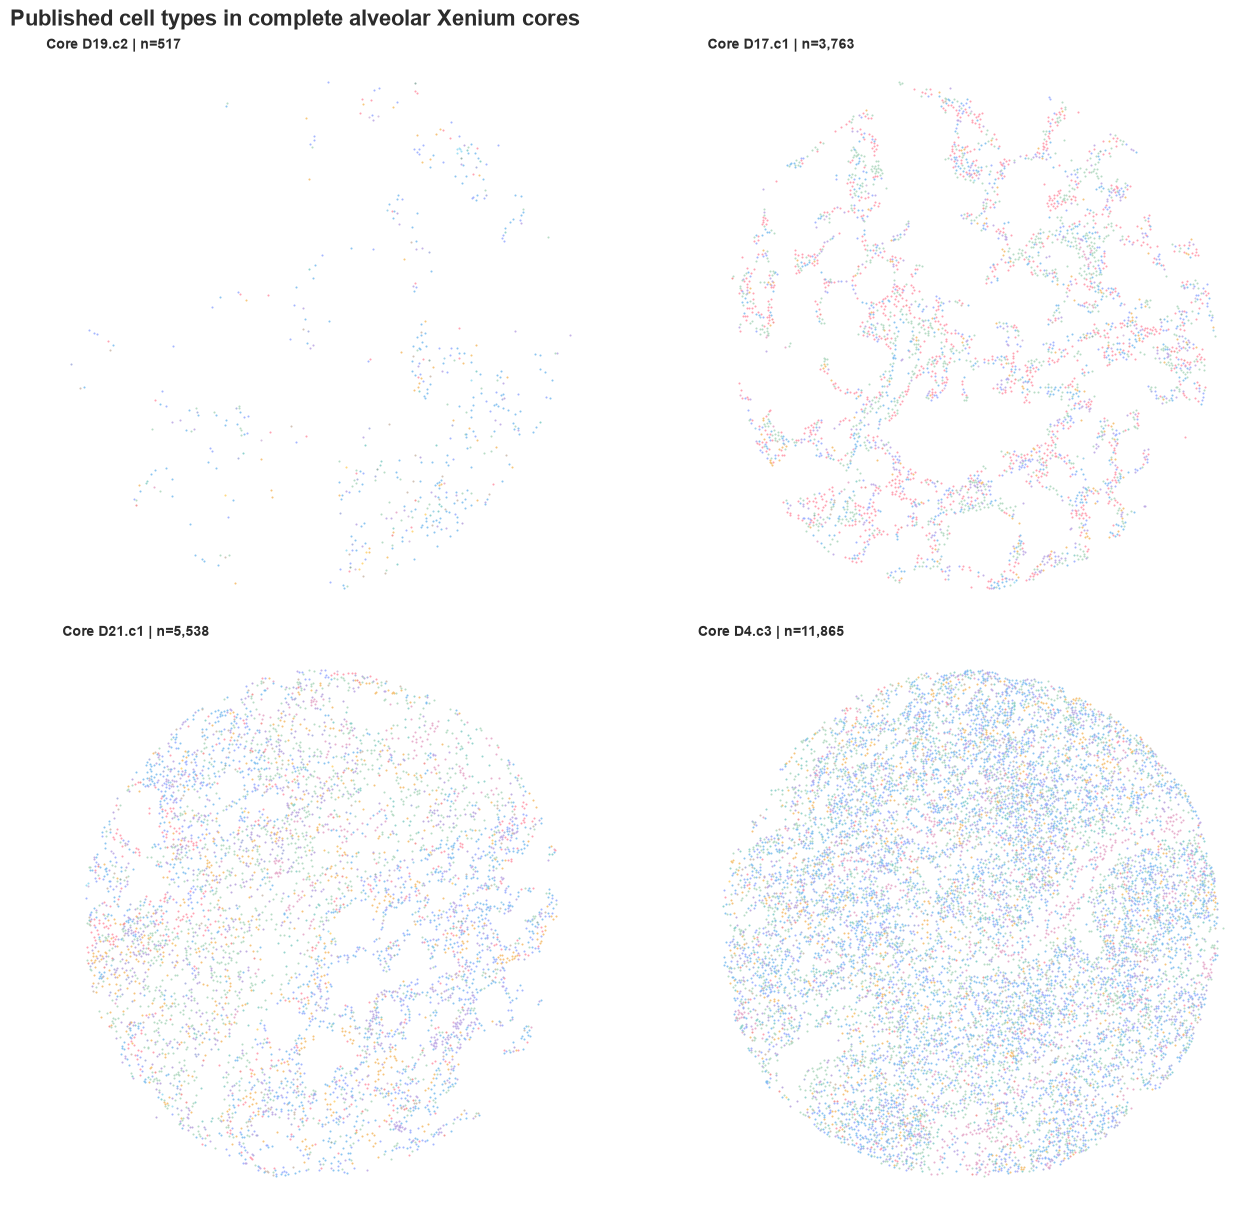

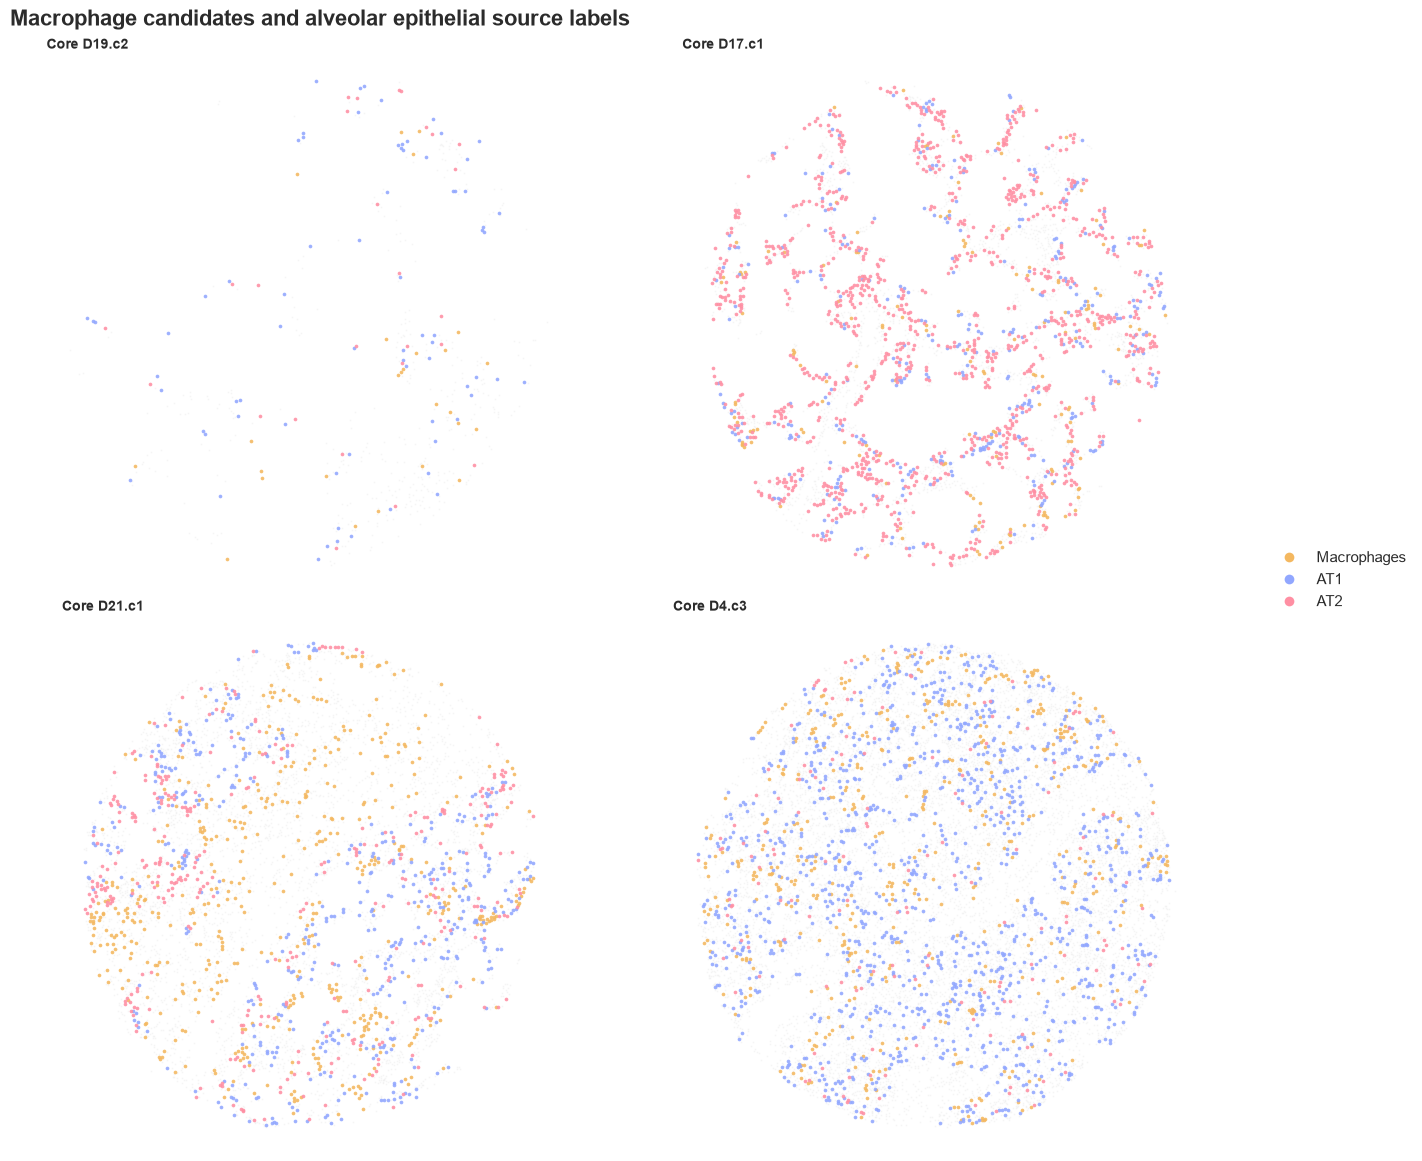

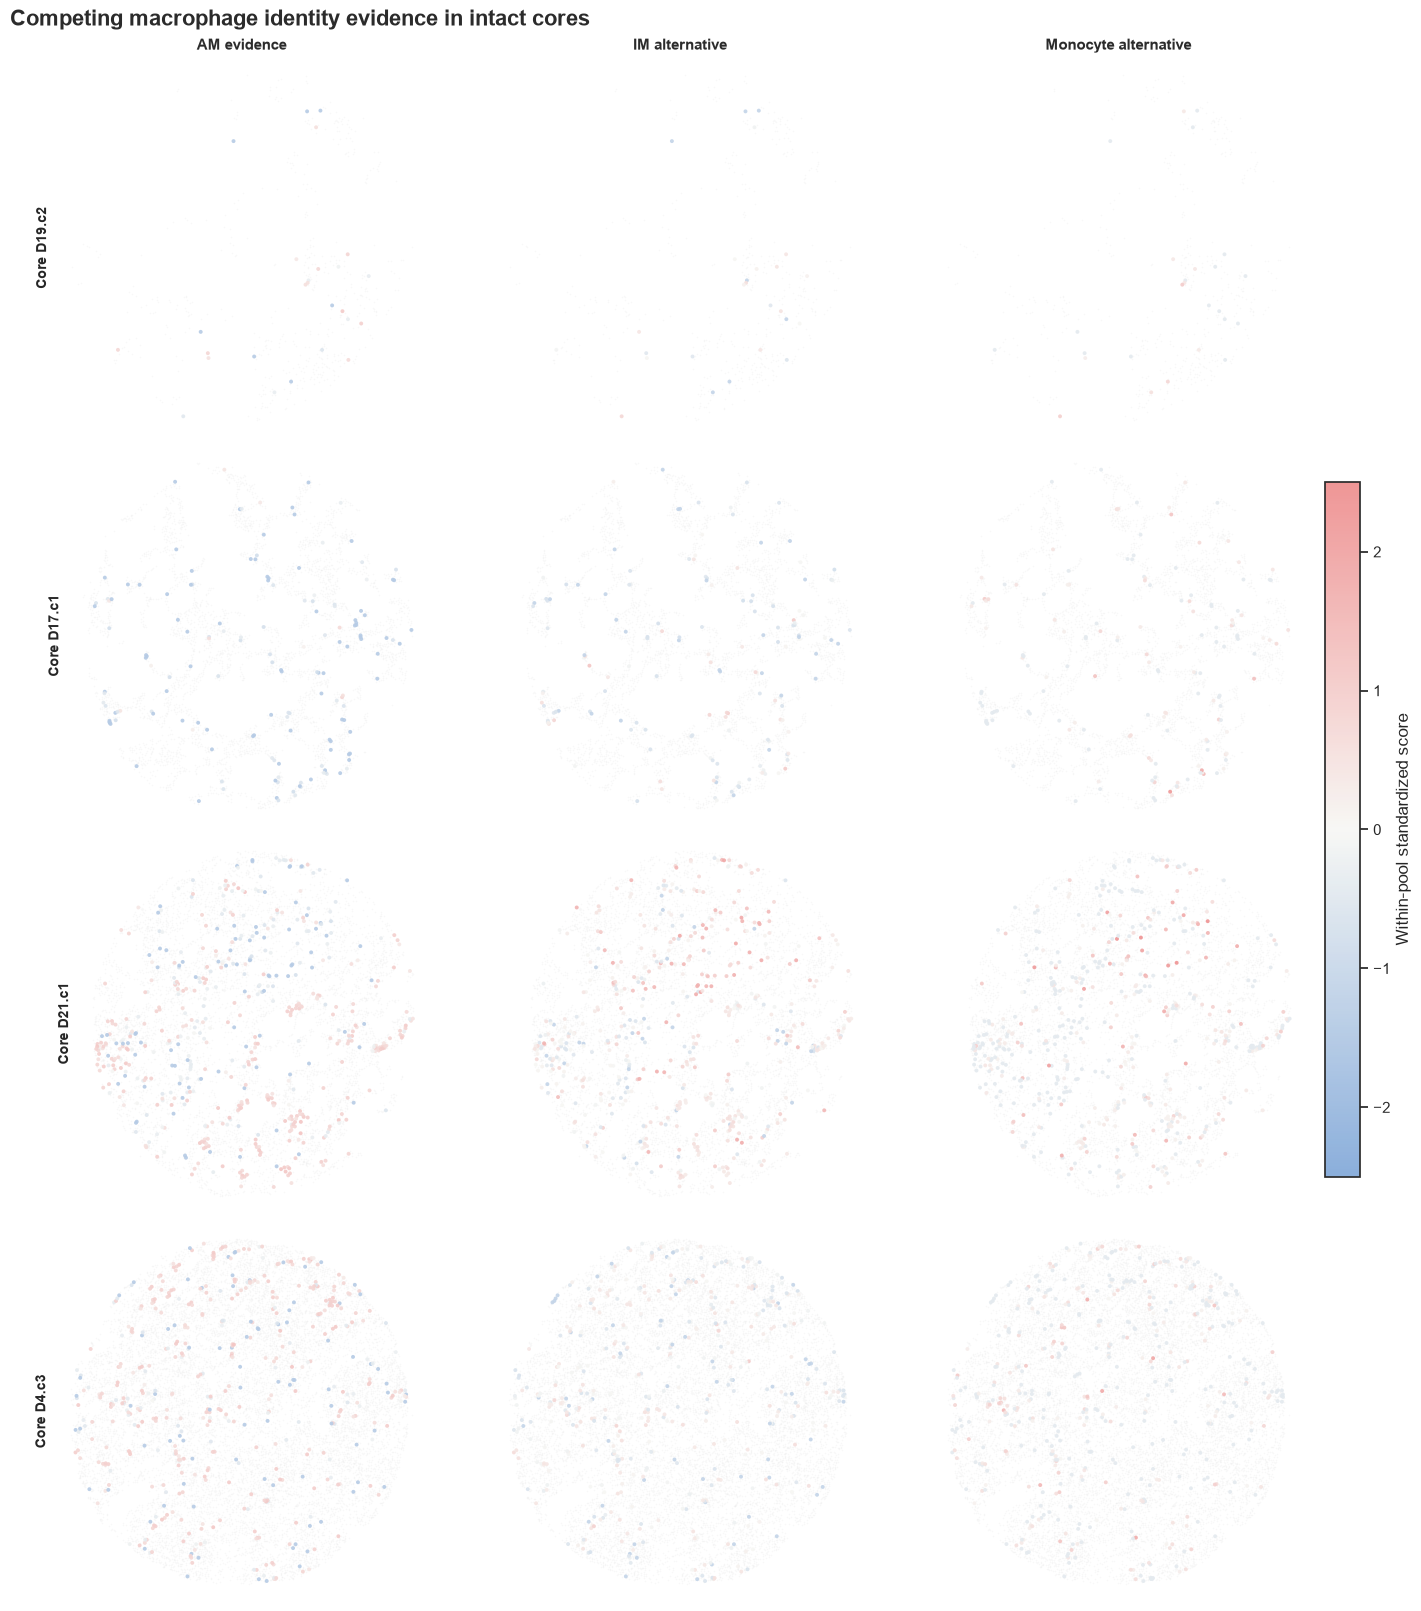

In [6]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import sparse

FIGURE_DIR = OUTPUT_ROOT / "figures"
TABLE_DIR = OUTPUT_ROOT / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DPI = 180 if RUN_MODE == "local_test" else 300
rng = np.random.default_rng(RANDOM_SEED)

sns.set_theme(style="white", context="notebook")
mpl.rcParams.update({
    "font.family": "Arial", "font.sans-serif": ["Arial", "DejaVu Sans"],
    "axes.edgecolor": "#2B2B2B", "text.color": "#2B2B2B",
    "pdf.fonttype": 42, "figure.facecolor": "white", "axes.facecolor": "white",
})

palette = {
    "AT1":"#91A7FF","AT2":"#FF8FA3","Macrophages":"#F4B860",
    "Monocytes":"#B8A1E3","DC":"#77C8C4","Endothelial":"#73B9EE",
    "LymphaticEC":"#80CBC4","Fibroblasts":"#A8D5BA","SmoothMuscle":"#E4A0C4",
    "Pericytes":"#C8B6A6","CD8T":"#9FA8DA","CD4T":"#B39DDB",
    "NK":"#8ECAE6","B":"#FFD166","Plasma":"#F6BD60","Mast":"#F28482",
    "Secretory":"#84A59D","Multiciliated":"#90DBF4","Basal":"#CDB4DB",
}
focus_palette = {"Macrophages":"#F4B860","AT1":"#91A7FF","AT2":"#FF8FA3"}
context_grey = "#D9D9D9"
program_cmap = LinearSegmentedColormap.from_list(
    "macaron_diverging", ["#7EA6D8", "#F7F7F4", "#EE8B8B"]
)

def savefig(fig, stem):
    fig.savefig(FIGURE_DIR / f"{stem}.png", dpi=FIGURE_DPI, bbox_inches="tight", facecolor="white")
    fig.savefig(FIGURE_DIR / f"{stem}.pdf", bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)

def clean_axis(ax, xlab="UMAP 1", ylab="UMAP 2"):
    ax.set_xlabel(xlab); ax.set_ylabel(ylab)
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines[["top","right"]].set_visible(False)

def stratified_indices(labels, maximum):
    labels = np.asarray(labels)
    pieces = []
    for label in pd.unique(labels):
        idx = np.flatnonzero(labels == label)
        pieces.append(rng.choice(idx, maximum, replace=False) if len(idx) > maximum else idx)
    return np.concatenate(pieces)

marker_modules = {
    "AT1 evidence":["AGER","SCEL"],
    "AT2 evidence":["SFTPD","PLA2G4F"],
    "AM evidence":["MARCO","APOE"],
    "IM alternative":["LYVE1","CD163","FCGR3A","MS4A4A"],
    "Monocyte alternative":["FCN1","S100A12","IL1B","CLEC4E"],
    "Pan-macrophage":["CD68","AIF1","MPEG1","TYROBP"],
}
unmeasured_checks = [
    "FABP4","PPARG","INHBA","SIGLEC1","ITGAX","CD36","ABCG1",
    "FOLR2","MRC1","C1QA","C1QB","C1QC","SFTPC",
]
marker_order = [g for genes in marker_modules.values() for g in genes]
marker_availability = {g: bool(g in adata.var_names) for g in marker_order + unmeasured_checks}
present = [g for g in marker_order if marker_availability[g]]
availability_table = pd.DataFrame([
    {"gene":g, "available":marker_availability[g],
     "module":next((m for m, genes in marker_modules.items() if g in genes), "canonical check")}
    for g in marker_order + unmeasured_checks
])
availability_table.to_csv(TABLE_DIR / "marker_availability.csv", index=False)
display(availability_table)

analysis_idx = np.flatnonzero(selected_mask.to_numpy()) if RUN_MODE == "local_test" else np.arange(adata.n_obs)
analysis_obs = obs.iloc[analysis_idx].copy()
xmat = adata[analysis_idx, present].X
raw_columns = pd.Index(adata.raw.var_names).get_indexer(present)
assert (raw_columns >= 0).all()
rmat = adata.raw.X[analysis_idx, :][:, raw_columns]
xmat = xmat.toarray() if sparse.issparse(xmat) else np.asarray(xmat)
rmat = rmat.toarray() if sparse.issparse(rmat) else np.asarray(rmat)
assert rmat.shape == xmat.shape
assert np.allclose(rmat[:min(1000, len(rmat))], np.round(rmat[:min(1000, len(rmat))]))
zero_pattern_concordance = float(np.mean((xmat > 0) == (rmat > 0)))
assert zero_pattern_concordance > 0.999, zero_pattern_concordance
expression_semantics = {
    "X":"non-negative transformed/log-normalized expression",
    "raw.X":"non-negative integer-like transcript counts",
    "dotplot_color":"mean X across all cells in group",
    "dotplot_size":"fraction raw.X > 0",
}

groups = ["AT1","AT2","Macrophages","Monocytes"]
rows = []
for group in groups:
    mask = analysis_obs["celltype_final"].astype(str).eq(group).to_numpy()
    assert mask.sum() > 0
    for j, gene in enumerate(present):
        rows.append({
            "source_celltype":group, "gene":gene,
            "module":next(m for m, genes in marker_modules.items() if gene in genes),
            "n_cells":int(mask.sum()),
            "mean_log_normalized_expression":float(xmat[mask, j].mean()),
            "fraction_detected_raw_gt_0":float((rmat[mask, j] > 0).mean()),
        })
marker_summary = pd.DataFrame(rows)
assert marker_summary["fraction_detected_raw_gt_0"].between(0, 1).all()
marker_summary.to_csv(TABLE_DIR / "annotation_marker_summary.csv", index=False)
display(marker_summary.head(12))

labels = obs["celltype_final"].astype(str).to_numpy()
umap = np.asarray(adata.obsm["X_umap"])
spatial = np.asarray(adata.obsm["spatial"])
max_per = 3500 if RUN_MODE == "local_test" else 8000
plot_idx = stratified_indices(labels, max_per)

fig, ax = plt.subplots(figsize=(10.5, 8))
for label in celltype_counts.index:
    idx = plot_idx[labels[plot_idx] == label]
    ax.scatter(umap[idx,0], umap[idx,1], s=4.5, c=palette[label], alpha=.78,
               linewidths=0, rasterized=True, label=f"{label} ({celltype_counts[label]:,})")
clean_axis(ax)
ax.set_title("Published human lung Xenium atlas", loc="left", fontsize=15, weight="bold")
ax.text(0,1.01,"Source UMAP; stratified display sample, full counts in legend",
        transform=ax.transAxes, fontsize=9, color="#666666")
ax.legend(bbox_to_anchor=(1.02,1), loc="upper left", frameon=False, markerscale=2.5, fontsize=8)
savefig(fig, "umap_all_celltypes")

focus = ["Macrophages","AT1","AT2"]
context_idx = stratified_indices(labels, 1800 if RUN_MODE == "local_test" else 3500)
focus_idx = np.flatnonzero(np.isin(labels, focus))
if RUN_MODE == "local_test" and len(focus_idx) > 65000:
    focus_idx = rng.choice(focus_idx, 65000, replace=False)
fig, ax = plt.subplots(figsize=(9.2,7.2))
ax.scatter(umap[context_idx,0], umap[context_idx,1], s=3, c=context_grey, alpha=.28,
           linewidths=0, rasterized=True)
for label in focus:
    idx = focus_idx[labels[focus_idx] == label]
    ax.scatter(umap[idx,0], umap[idx,1], s=6, c=focus_palette[label], alpha=.78,
               linewidths=0, rasterized=True, label=label)
clean_axis(ax)
ax.set_title("Macrophage, AT1, and AT2 source labels", loc="left", fontsize=15, weight="bold")
ax.text(0,1.01,"Macrophages = candidate pool only; other labels in pale grey",
        transform=ax.transAxes, fontsize=9, color="#666666")
ax.legend(frameon=False, markerscale=2.8)
savefig(fig, "umap_focus_macrophage_AT1_AT2")

dot = marker_summary.copy()
xpos = {g:i for i,g in enumerate(marker_order)}
ypos = {g:i for i,g in enumerate(groups[::-1])}
fig, ax = plt.subplots(figsize=(14.5,4.7))
sc = ax.scatter(dot["gene"].map(xpos), dot["source_celltype"].map(ypos),
    s=22+330*dot["fraction_detected_raw_gt_0"],
    c=dot["mean_log_normalized_expression"],
    cmap=LinearSegmentedColormap.from_list("macaron_expression",["#F5F3F8","#9BBFE0","#E98A9B"]),
    linewidths=.45, edgecolors="white")
ax.set_xticks(range(len(marker_order)), marker_order, rotation=55, ha="right")
ax.set_yticks(range(len(groups)), groups[::-1])
ax.set_xlim(-.7,len(marker_order)-.3); ax.set_ylim(-.7,len(groups)-.3)
ax.grid(axis="x", color="#EEEEEE", linewidth=.6)
ax.spines[["top","right","left","bottom"]].set_visible(False); ax.tick_params(length=0)
ax.set_title("Marker evidence by published cell-type label", loc="left", fontsize=15, weight="bold")
ax.text(0,1.04,"Color: mean log-normalized expression | Area: fraction with raw count > 0",
        transform=ax.transAxes, fontsize=9, color="#666666")
fig.colorbar(sc, ax=ax, pad=.02, fraction=.025, label="Mean log-normalized expression")
savefig(fig, "dotplot_annotation_markers")

expr = pd.DataFrame(xmat, index=analysis_obs.index, columns=present)
macmask = analysis_obs["celltype_final"].astype(str).eq("Macrophages").to_numpy()
macexpr = expr.loc[macmask]
z = (macexpr - macexpr.mean()) / macexpr.std(ddof=0).replace(0, np.nan)
score_modules = {
    "AM evidence":marker_modules["AM evidence"],
    "IM alternative":marker_modules["IM alternative"],
    "Monocyte alternative":marker_modules["Monocyte alternative"],
}
scores = pd.DataFrame(index=macexpr.index)
for module, genes in score_modules.items():
    scores[module] = z[[g for g in genes if g in z]].mean(axis=1)
scores.to_csv(TABLE_DIR / "macrophage_candidate_program_scores_local_or_full.csv")
display(scores.describe().T)
mac_global = analysis_idx[macmask]
norm = TwoSlopeNorm(vmin=-2.5, vcenter=0, vmax=2.5)
fig, axes = plt.subplots(1,3,figsize=(14.2,4.7), constrained_layout=True)
for ax, module in zip(axes, score_modules):
    last = ax.scatter(umap[mac_global,0],umap[mac_global,1],
        c=scores[module].clip(-2.5,2.5), cmap=program_cmap, norm=norm,
        s=7, alpha=.88, linewidths=0, rasterized=True)
    clean_axis(ax); ax.set_title(module, fontsize=11, weight="bold")
fig.suptitle("Competing evidence inside the macrophage candidate pool",
             x=.01, ha="left", fontsize=15, weight="bold")
fig.colorbar(last, ax=axes, shrink=.72, pad=.02, label="Within-pool standardized score")
savefig(fig, "umap_macrophage_identity_features")

fig, axes = plt.subplots(2,2,figsize=(13,12), constrained_layout=True)
for ax, core in zip(axes.flat, selected_cores):
    idx = np.flatnonzero(obs["core_id"].astype(str).eq(core).to_numpy())
    for label in celltype_counts.index[::-1]:
        ii = idx[labels[idx] == label]
        if len(ii):
            ax.scatter(spatial[ii,0],spatial[ii,1],s=2.2,c=palette[label],alpha=.82,
                       linewidths=0,rasterized=True)
    ax.set_title(f"Core {core} | n={len(idx):,}",loc="left",fontsize=10,weight="bold")
    ax.set_aspect("equal"); ax.invert_yaxis(); ax.set_xticks([]); ax.set_yticks([]); ax.spines[:].set_visible(False)
fig.suptitle("Published cell types in complete alveolar Xenium cores",x=.01,ha="left",fontsize=16,weight="bold")
savefig(fig, "spatial_all_celltypes")

fig, axes = plt.subplots(2,2,figsize=(12.5,11.5), constrained_layout=True)
for ax, core in zip(axes.flat, selected_cores):
    idx = np.flatnonzero(obs["core_id"].astype(str).eq(core).to_numpy())
    ax.scatter(spatial[idx,0],spatial[idx,1],s=1.6,c=context_grey,alpha=.24,linewidths=0,rasterized=True)
    for label in focus:
        ii = idx[labels[idx] == label]
        ax.scatter(spatial[ii,0],spatial[ii,1],s=7,c=focus_palette[label],alpha=.88,
                   linewidths=0,rasterized=True,label=label)
    ax.set_title(f"Core {core}",loc="left",fontsize=10,weight="bold")
    ax.set_aspect("equal"); ax.invert_yaxis(); ax.set_xticks([]); ax.set_yticks([]); ax.spines[:].set_visible(False)
fig.suptitle("Macrophage candidates and alveolar epithelial source labels",x=.01,ha="left",fontsize=16,weight="bold")
handles=[Line2D([0],[0],marker="o",color="none",markerfacecolor=focus_palette[x],markeredgewidth=0,markersize=7,label=x) for x in focus]
fig.legend(handles=handles,bbox_to_anchor=(1.01,.5),loc="center left",frameon=False)
savefig(fig, "spatial_focus_macrophage_AT1_AT2")

name_to_global = pd.Series(mac_global,index=scores.index)
fig, axes = plt.subplots(len(selected_cores),3,figsize=(14.2,4*len(selected_cores)),constrained_layout=True)
for row, core in enumerate(selected_cores):
    idx = np.flatnonzero(obs["core_id"].astype(str).eq(core).to_numpy())
    names = obs.index[idx[labels[idx] == "Macrophages"]].intersection(scores.index)
    gidx = name_to_global.loc[names].to_numpy(dtype=int)
    for col,module in enumerate(score_modules):
        ax=axes[row,col]
        ax.scatter(spatial[idx,0],spatial[idx,1],s=1.3,c=context_grey,alpha=.18,linewidths=0,rasterized=True)
        last=ax.scatter(spatial[gidx,0],spatial[gidx,1],c=scores.loc[names,module].clip(-2.5,2.5),
                        cmap=program_cmap,norm=norm,s=8,alpha=.9,linewidths=0,rasterized=True)
        if row==0: ax.set_title(module,fontsize=11,weight="bold")
        if col==0: ax.set_ylabel(f"Core {core}",fontsize=10,weight="bold")
        ax.set_aspect("equal"); ax.invert_yaxis(); ax.set_xticks([]); ax.set_yticks([]); ax.spines[:].set_visible(False)
fig.suptitle("Competing macrophage identity evidence in intact cores",x=.01,ha="left",fontsize=16,weight="bold")
fig.colorbar(last,ax=axes,shrink=.45,pad=.015,label="Within-pool standardized score")
savefig(fig, "spatial_macrophage_identity_features")


### 7. Final machine-readable execution record

The JSON and CSV tables make every plotted definition and statistic auditable. The unresolved AM status is recorded deliberately.

In [7]:
summary.update({
    "expression_semantics": expression_semantics,
    "expression_zero_pattern_concordance": zero_pattern_concordance,
    "marker_availability": marker_availability,
    "missing_markers": [g for g, available in marker_availability.items() if not available],
    "analysis_cells": int(len(analysis_idx)),
    "figure_stems": [
        "umap_all_celltypes","umap_focus_macrophage_AT1_AT2",
        "dotplot_annotation_markers","umap_macrophage_identity_features",
        "spatial_all_celltypes","spatial_focus_macrophage_AT1_AT2",
        "spatial_macrophage_identity_features",
    ],
    "am_definition_status": "not_finalized_macrophage_candidate_pool_only",
    "mhcii_state_status": "not_assigned_in_notebook_00",
})
summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")
display(pd.Series({
    "source cells":summary["n_cells"], "panel genes":summary["n_genes"],
    "analysis cells":summary["analysis_cells"], "figures":len(summary["figure_stems"]),
    "AM status":summary["am_definition_status"],
}, name="value").to_frame())

,value
source cells,332063
panel genes,389
analysis cells,21683
figures,7
AM status,not_finalized_macrophage_candidate_pool_only


## Takeaways

- The deposited UMAP and all published labels are shown before AM subtyping.
- AT1 and AT2 are checked using measured marker pairs; an absent panel gene such as SFTPC is not interpreted as negative expression.
- Macrophages remains a broad candidate pool. AM evidence is shown beside IM and monocyte alternatives.
- Program scores are descriptive, panel-constrained, and relative within the candidate pool. They are not a final AM gate.
- Cycling AM are not analyzed and MHCII-high/low states are not assigned in notebook 00.
- The next notebook should define the AM inclusion/exclusion rule only after these diagnostic plots are reviewed. Later inference must use donor, not cell, as the biological replicate.